# RetailSense AI
## Notebook 10 . Supply Chain Inventory Recommendations
---
**Organization:** Celebal Technologies &nbsp;|&nbsp; **Intern:** Ayush Choudhary  
**Domain:** Data Science . Time Series Forecasting . Inventory Intelligence  
**Dataset:** [Kaggle Store-Item Demand Forecasting](https://www.kaggle.com/competitions/demand-forecasting-kernels-only)
 -- 913 K records . 10 Stores . 50 Items . 5 Years (2013-2017)

---

### Objective
Convert model forecasts into **automated procurement decisions** using
supply chain engineering formulas:

$$SS = Z \cdot \sigma_d \cdot \sqrt{L}, \quad ROP = \bar{d} \cdot L + SS$$


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})


### Generate Store-Item Recommendations

In [2]:
from src.data.loader import load_raw_data
from src.features.build_features import build_all_features
from src.models.advanced import train_xgboost
from src.recommendation.inventory import generate_store_item_recommendations

# Load data and train model
train_df, _ = load_raw_data()
df_feat = build_all_features(train_df).dropna().reset_index(drop=True)

feature_cols = [c for c in df_feat.columns if c not in ['date', 'sales', 'store', 'item']]
X = df_feat[feature_cols]
y = df_feat['sales']
model = train_xgboost(X, y)

# Create forecast DataFrame
np.random.seed(42)
forecast_df = df_feat[['store', 'item']].copy()
forecast_df['forecast'] = model.predict(X)

# Generate recommendations
recs = generate_store_item_recommendations(forecast_df, train_df)
print(f"Recommendations generated for {len(recs)} store-item combinations")
print(f"\nStatus Distribution:")
print(recs['Status'].value_counts().to_string())


Memory usage optimized from 27.86 MB to 10.45 MB (62.5% reduction).
Memory usage optimized from 1.37 MB to 0.60 MB (56.2% reduction).
Recommendations generated for 500 store-item combinations

Status Distribution:
Status
URGENT REORDER    342
OPTIMAL           158


### Recommendation Matrix (Top 15 by ROP)

In [3]:
top15 = recs.nlargest(15, 'Reorder Point (ROP)').reset_index(drop=True)

display(top15.style.applymap(
    lambda v: 'background-color:#fef2f2;color:#dc2626;font-weight:bold' if 'URGENT' in str(v)
              else ('background-color:#f0fdf4;color:#16a34a' if 'OPTIMAL' in str(v)
              else 'background-color:#fffbeb;color:#d97706'),
    subset=['Status']
).format({'Daily Forecast Mean': '{:.1f}', 'Lead Time Demand': '{:.0f}',
          'Safety Stock': '{:.0f}', 'Reorder Point (ROP)': '{:.0f}',
          'Current Stock': '{:.0f}'})
 .set_caption("Top-15 Store-Item Procurement Recommendations (Ordered by ROP)"))


,Store,Item,Daily Forecast Mean,Lead Time Demand,Safety Stock,Reorder Point (ROP),Current Stock,Status,Recommended Action
0,2,15,113.9,797,130,927,714,URGENT REORDER,Place order for 342 units immediately.
1,2,28,113.8,796,129,925,598,URGENT REORDER,Place order for 456 units immediately.
2,2,18,109.5,766,125,891,966,OPTIMAL,Stock levels are optimal. Maintain current schedule.
3,2,13,109.2,765,124,889,978,OPTIMAL,Stock levels are optimal. Maintain current schedule.
4,8,15,109.4,766,124,889,1040,OPTIMAL,Stock levels are optimal. Maintain current schedule.
5,8,28,109.2,764,124,888,547,URGENT REORDER,Place order for 465 units immediately.
6,8,18,105.3,737,120,857,982,OPTIMAL,Stock levels are optimal. Maintain current schedule.
7,8,13,105.2,737,119,856,751,URGENT REORDER,Place order for 223 units immediately.
8,2,25,104.8,734,121,855,876,OPTIMAL,Stock levels are optimal. Maintain current schedule.
9,2,45,104.8,734,120,854,909,OPTIMAL,Stock levels are optimal. Maintain current schedule.


### Inventory Health Visualization

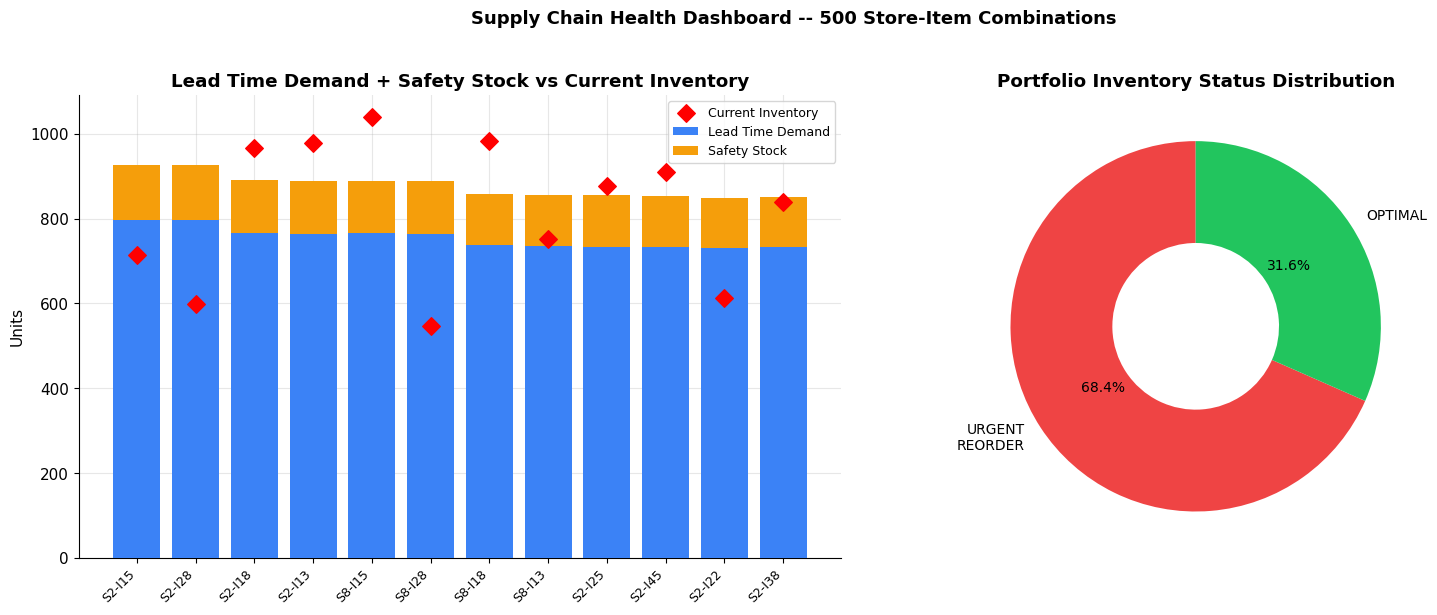

In [4]:
top12 = recs.nlargest(12, 'Reorder Point (ROP)').copy()
top12['label'] = 'S' + top12['Store'].astype(str) + '-I' + top12['Item'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Stacked bar (LTD + Safety Stock) vs Current Stock
x = np.arange(len(top12))
axes[0].bar(x, top12['Lead Time Demand'].values, label='Lead Time Demand', color='#3b82f6', zorder=3)
axes[0].bar(x, top12['Safety Stock'].values, bottom=top12['Lead Time Demand'].values,
            label='Safety Stock', color='#f59e0b', zorder=3)
axes[0].scatter(x, top12['Current Stock'].values, color='red', zorder=5, s=80,
                marker='D', label='Current Inventory')
axes[0].set_xticks(x)
axes[0].set_xticklabels(top12['label'].values, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Lead Time Demand + Safety Stock vs Current Inventory', fontweight='bold')
axes[0].set_ylabel('Units')
axes[0].legend(fontsize=9)

# Right: Status distribution pie
status_counts = recs['Status'].value_counts()
pie_labels = status_counts.index.tolist()
pie_colors = ['#22c55e' if 'OPTIMAL' in l else '#ef4444' if 'URGENT' in l else '#f59e0b' for l in pie_labels]
axes[1].pie(status_counts.values, labels=[l.replace('URGENT REORDER', 'URGENT\nREORDER') for l in pie_labels],
            autopct='%1.1f%%', colors=pie_colors, startangle=90,
            wedgeprops=dict(width=0.55), textprops={'fontsize': 10})
axes[1].set_title('Portfolio Inventory Status Distribution', fontweight='bold')

plt.suptitle('Supply Chain Health Dashboard -- 500 Store-Item Combinations',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


---
### Business Interpretation

| Action | Criteria | Impact |
|:-------|:---------|:-------|
| **URGENT REORDER** | Current Stock < ROP | Prevents imminent stockout; protects revenue |
| **OVERSTOCKED** | Current Stock > 1.5 x Target | Frees capital; reduces holding cost |
| **OPTIMAL** | ROP <= Current <= 1.5 x Target | No action needed; system is healthy |
